# Panda数据处理

In [20]:
import numpy as np
import pandas as pd

## 数据IO操作

### pandas IO操作主要是读取和写入数据，pandas支持多种数据格式的读写操作，包括CSV、Excel、SQL、JSON等。

In [21]:
# 读取 CSV 文件
df = pd.read_csv('csv文件.csv')
df

,姓名,年龄,城市
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


In [22]:
pd.read_csv("csv文件.csv", header=None)# header=None表示不将第一行作为列名，而是将其作为数据的一部分。

,0,1,2
0,姓名,年龄,城市
1,张三,28,北京
2,李四,31,上海
3,王五,25,广州


In [23]:
pd.read_csv("csv文件.csv", index_col="姓名")# index_col="姓名"表示将"姓名"列作为索引列。

,年龄,城市
姓名,,
张三,28,北京
李四,31,上海
王五,25,广州


#### pd.read_table()函数：读取以制表符（\t）分隔的文本文件，返回一个DataFrame对象。

In [24]:
df = pd.read_table("txt文件.txt", sep="\t", header=None)# sep="\t"表示以制表符（\t）作为分隔符。

In [25]:
df #因为 read_table()函数默认以制表符（\t）作为分隔符，所以可以直接使用read_table()函数读取制表符分隔的文本文件。但是，如果文本文件使用其他分隔符（如逗号、空格等），则需要使用read_csv()函数，并指定sep参数为相应的分隔符。

,0
0,张三 28 北京
1,李四 31 上海
2,王五 25 广州


In [26]:
df = pd.read_table("txt文件.txt", sep=" ", header=None, index_col=0)# index_col=0表示将第一列作为索引列。
df

,1,2
0,,
张三,28,北京
李四,31,上海
王五,25,广州


In [27]:
# 使用read_csv()函数读取制表符分隔的文本文件
df = pd.read_csv("txt文件.txt", sep=" ", header=None)

In [28]:
df

,0,1,2
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


In [29]:
pd.read_csv("csv文件 copy.csv", sep="-")

,姓名,年龄,城市
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


In [30]:
pd.read_csv("csv文件 copy 2.csv", sep="\\s+")# sep="\\s+"表示以一个或多个空格作为分隔符。

,姓名,年龄,城市
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


### excel读取

In [31]:
data1 =  pd.read_excel('excel文件.xlsx')# 读取 Excel 文件,默认读取第一个工作表。
data1

,编号,名称,数值
0,1,数据1,10
1,2,数据2,20
2,3,数据3,30
3,4,数据4,40
4,5,数据5,50


In [32]:
data2 = pd.read_excel('excel文件.xlsx', sheet_name='Sheet2')# 读取 Excel 文件的指定工作表。
data2

,编号,名称,数值
0,1,项目1,15
1,2,项目2,25
2,3,项目3,35
3,4,项目4,45
4,5,项目5,55


In [33]:
data1.to_excel('output.xlsx', index=False)# 将 DataFrame 保存为 Excel 文件，index=False表示不保存索引列。

In [34]:
data1.to_csv('output.csv', index=False)# 将 DataFrame 保存为 CSV 文件，index=False表示不保存索引列。

## 数据探索

- describe()函数：用于快速查看数据的统计信息，包括计数、均值、标准差、最小值、最大值等。
- info()函数：用于查看数据的基本信息，包括数据类型、非空值数量、内存占用等。
- tail()函数：用于查看数据的最后几行，默认显示最后5行。
- sample()函数：用于随机抽样数据，可以指定抽样的数量或比例。

In [35]:
df = pd.DataFrame(data=np.random.randint(1, 10000, size=(1000, 5)), columns=['A', 'B', 'C', 'D', 'E'])# 创建一个包含1000行、5列的随机整数数据的DataFrame，整数范围为1到9999。
df

,A,B,C,D,E
0,5459,9596,4137,6349,58
1,7803,5860,4455,9185,572
2,4371,2834,9674,5175,6265
3,408,9076,5778,5170,6096
4,2352,1109,8337,8959,3693
...,...,...,...,...,...
995,2498,7743,1375,2631,9853
996,2596,8967,6058,5891,1527
997,1408,6668,1291,5872,8446
998,3914,734,2088,1741,1906


In [36]:
df.describe(percentiles=[.25, .5, .75, .99])# describe()函数用于快速查看数据的统计信息，包括计数、均值、标准差、最小值、最大值等。percentiles参数用于指定要计算的分位数。

,A,B,C,D,E
count,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,4940.02300,4956.059000,5142.11900,4945.807000,5201.282000
std,2877.78915,2879.161201,2858.91292,2830.785308,2870.250632
min,11.00000,29.000000,22.00000,8.000000,7.000000
25%,2425.00000,2522.000000,2664.00000,2537.000000,2858.750000
50%,5039.00000,4835.000000,5221.50000,4970.000000,5205.000000
75%,7430.00000,7572.000000,7673.50000,7319.250000,7749.750000
99%,9864.14000,9840.120000,9883.08000,9885.460000,9853.140000
max,9969.00000,9988.000000,9991.00000,9986.000000,9971.000000


In [37]:
df.info()# info()函数用于查看DataFrame的基本信息，包括数据类型、非空值数量、内存占用等。

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       1000 non-null   int64
 1   B       1000 non-null   int64
 2   C       1000 non-null   int64
 3   D       1000 non-null   int64
 4   E       1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [38]:
df.head()# head()函数用于查看数据的前几行，默认显示前5行。

,A,B,C,D,E
0,5459,9596,4137,6349,58
1,7803,5860,4455,9185,572
2,4371,2834,9674,5175,6265
3,408,9076,5778,5170,6096
4,2352,1109,8337,8959,3693


In [39]:
df.tail(n = 10)# tail()函数用于查看数据的最后几行，n参数指定显示的行数，默认显示最后5行。

,A,B,C,D,E
990,9371,3695,8682,22,6504
991,6457,1181,2792,5493,5106
992,9561,7211,9972,4568,981
993,7001,2071,4620,5570,2232
994,8868,2958,8511,8602,9919
995,2498,7743,1375,2631,9853
996,2596,8967,6058,5891,1527
997,1408,6668,1291,5872,8446
998,3914,734,2088,1741,1906
999,6372,9826,2523,7088,4406


In [40]:
df.sample(n=5)# sample()函数用于随机抽样数据，n参数指定抽样的数量。

,A,B,C,D,E
447,6879,5353,6814,497,3407
592,5284,307,7826,1637,114
255,8533,414,1869,8504,7885
347,2760,4934,8602,5231,2287
992,9561,7211,9972,4568,981


## 空值处理

### None

- None是Python中的一个特殊对象，表示空值。其类型为python object。因此，None不能参与到数值计算中，也不能与其他类型进行比较操作。
- object类型的运算要比数值类型的运算慢很多，因此在数据分析中，尽量避免使用object类型的数据。

In [41]:
type(None)

NoneType

## np.nan(NaN)

- np.nan是NumPy库中的一个特殊浮点数，表示“不是一个数字”（Not a Number）。它通常用于表示缺失或无效的数值数据。与None不同，np.nan是一个浮点数类型，可以参与数值计算，但在计算中会被视为缺失值(NaN)。
- 在numpy和pandas中，可以使用np.nanxxx()函数来处理NaN值，此时视nan为0。
- 因为np.nan是一个浮点数类型，所以在数据分析中，尽量使用np.nan来表示缺失值，而不是None。

In [42]:
type(np.nan)

float

In [43]:
def getsum(x):
    return x.sum()

In [44]:
data1 = np.arange(1, 10000001, dtype=object)

In [45]:
%timeit getsum(data1)

79.7 ms ± 1.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [46]:
data2 = np.arange(1, 10000001, dtype=np.float64)

In [47]:
%timeit getsum(data2)

1.25 ms ± 72.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### pandas自动把None转换为np.nan

In [48]:
df = pd.DataFrame(data=np.random.randint(0, 10, size=(3, 5)), columns=['A', 'B', 'C', 'D', 'E'])# 创建一个包含100行5列的随机数DataFrame，列名为'A'、'B'、'C'、'D'和'E'。

In [49]:
df

,A,B,C,D,E
0,3,7,5,1,3
1,4,1,1,1,9
2,7,4,7,3,8


In [50]:
df.loc[2] = None# loc[]函数用于根据标签选择数据，df.loc[2]表示选择索引为2的行。将其赋值为None表示将该行的所有列的值都设置为缺失值。

In [51]:
df

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0
2,NaN,NaN,NaN,NaN,NaN


> NaN 是一个符号，表示“不是一个数字”（Not a Number），不是一个具体的数值。   
> 在pandas中，None和np.nan 都会被显示为缺失值(NaN).  

### 空值查找

- isnull()函数：用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。
- notnull()函数：用于判断数据是否为非缺失值，返回一个布尔型的DataFrame或Series对象，非缺失值为True，缺失值为False。

In [52]:
df

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0
2,NaN,NaN,NaN,NaN,NaN


In [53]:
df.isnull()# isnull()函数用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。

,A,B,C,D,E
0,False,False,False,False,False
1,False,False,False,False,False
2,True,True,True,True,True


- any()函数：用于检查DataFrame或Series中是否存在任何True值。如果存在至少一个True值，返回True；否则返回False。默认情况下，any()函数沿着列方向（axis=0）进行操作，即检查每一列是否存在True值。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。
- all()函数：用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

In [54]:
df.isnull().any()# any()函数用于检查DataFrame或Series中是否存在任何True值。如果存在至少一个True值，返回True；否则返回False。默认情况下，any()函数沿着列方向（axis=0）进行操作，即检查每一列是否存在True值。

A    True
B    True
C    True
D    True
E    True
dtype: bool

In [55]:
df.isnull().any(axis=1)# all()函数用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

0    False
1    False
2     True
dtype: bool

In [56]:
# 找出至少包含一个缺失值的行
df[df.isnull().any(axis=1)]# df.isnull().any(axis=1)返回一个布尔型的Series对象，表示每一行是否包含至少一个缺失值。然后使用布尔索引df[...]选择出包含至少一个缺失值的行

,A,B,C,D,E
2,NaN,NaN,NaN,NaN,NaN


In [57]:
# 找出至少包含一个缺失值的列
df.loc[:, df.isnull().any()]# df.isnull().any()返回一个布尔型的Series对象，表示每一列是否包含至少一个缺失值。然后使用布尔索引df.loc[:, ...]选择出包含至少一个缺失值的列

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0
2,NaN,NaN,NaN,NaN,NaN


In [58]:
df.notnull()# notnull()函数用于判断数据是否为非缺失值，返回一个布尔型的DataFrame或Series对象，非缺失值为True，缺失值为False。

,A,B,C,D,E
0,True,True,True,True,True
1,True,True,True,True,True
2,False,False,False,False,False


In [59]:
df.notnull().all(axis=1)# all()函数用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。

0     True
1     True
2    False
dtype: bool

In [60]:
# 取出所有非缺失值的行
df[df.notnull().all(axis=1)]# df.notnull().all(axis=1)返回一个布尔型的Series对象，表示每一行是否所有值都为非缺失值。然后使用布尔索引df[...]选择出所有非缺失值的行

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0


In [61]:
# 查看某一列的空值占比
df.isnull().mean()# isnull()函数用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。mean()函数用于计算每一列的平均值，即空值占比。 

A    0.333333
B    0.333333
C    0.333333
D    0.333333
E    0.333333
dtype: float64

> 列字段是不能轻易删除的

### 空值填充

fillna()函数：用于填充缺失值(NaN)，可以指定填充值或使用前一个/后一个有效值进行填充。

In [62]:
df

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0
2,NaN,NaN,NaN,NaN,NaN


In [63]:
df.fillna(value=0)# fillna()函数用于填充缺失值(NaN)，可以指定填充值或使用前一个/后一个有效值进行填充。

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0
2,0.0,0.0,0.0,0.0,0.0


In [64]:
df.mean()# mean()函数用于计算每一列的均值，返回一个包含每一列均值的Series对象。

A    3.5
B    4.0
C    3.0
D    1.0
E    6.0
dtype: float64

In [65]:
# 使用均值来填充缺失值
df.fillna(value=df.mean())# df.mean()计算每一列的均值，然后使用fillna()函数将缺失值填充为对应列的均值。

,A,B,C,D,E
0,3.0,7.0,5.0,1.0,3.0
1,4.0,1.0,1.0,1.0,9.0
2,3.5,4.0,3.0,1.0,6.0


In [66]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。

In [67]:
df

,A,B,C
0,18,85,32
1,27,26,69
2,81,91,49
3,93,22,89
4,76,99,9
5,71,42,3
6,92,95,24
7,64,84,91
8,0,71,5
9,81,1,78


In [68]:
df.loc[3, 'B'] = None# loc[]函数用于根据标签选择数据，df.loc[3, 'B']表示选择索引为3的行和列名为'B'的列。将其赋值为None表示将该单元格的值设置为缺失值。
df.loc[5, 'C'] = None# loc[]函数用于根据标签选择数据，df.loc[5, 'C']表示选择索引为5的行和列名为'C'的列。将其赋值为None表示将该单元格的值设置为缺失值。
df.loc[9] = None# loc[]函数用于根据标签选择数据，df.loc[9]表示选择索引为9的行。将其赋值为None表示将该行的所有列的值都设置为缺失值。

In [69]:
df

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


In [70]:
df.mean(axis=1)# mean()函数用于计算每一列的均值，返回一个包含每一列均值的Series对象。

0    45.000000
1    40.666667
2    73.666667
3    91.000000
4    61.333333
5    56.500000
6    70.333333
7    79.666667
8    25.333333
9          NaN
dtype: float64

In [71]:
df.fillna(value=df.mean(axis=1), axis=1)# fillna()函数用于填充缺失值(NaN)，可以指定填充值或使用前一个/后一个有效值进行填充。value=df.mean(axis=1)表示使用每一行的均值来填充缺失值，axis=0表示沿着列方向进行填充。

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,91.0,89.0
4,76.0,99.0,9.0
5,71.0,42.0,56.5
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


In [72]:
# 使用临近值填充
df.ffill(axis=1)# ffill()函数用于使用前一个有效值来填充缺失值(NaN)，axis=1表示沿着行方向进行填充，即使用每一行的前一个有效值来填充缺失值。

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,93.0,89.0
4,76.0,99.0,9.0
5,71.0,42.0,42.0
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


In [73]:
# 向后填充
df.bfill(axis=0)# bfill()函数用于使用后一个有效值来填充缺失值(NaN)，axis=1表示沿着行方向进行填充，即使用每一行的后一个有效值来填充缺失值。

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,99.0,89.0
4,76.0,99.0,9.0
5,71.0,42.0,24.0
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


In [74]:
df

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


### 空值过滤

dropna()函数：用于删除缺失值(NaN)所在的行或列。可以通过设置参数axis=0或axis=1来指定删除行或列，默认情况下删除行。

In [75]:
df

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


In [76]:
df.notnull()# isnull()函数用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。

,A,B,C
0,True,True,True
1,True,True,True
2,True,True,True
3,True,False,True
4,True,True,True
5,True,True,False
6,True,True,True
7,True,True,True
8,True,True,True
9,False,False,False


In [77]:
df.notnull().any(axis=1)# all()函数用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9    False
dtype: bool

In [78]:
df.loc[df.notnull().any(axis=1)]# df.notnull().all(axis=1)返回一个布尔型的Series对象，表示每一行是否所有值都为非缺失值。然后使用布尔索引df.loc[...]选择出所有值都为非缺失值的行。

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0


In [79]:
# 过滤掉A列中包含缺失值的行
df['A']

0    18.0
1    27.0
2    81.0
3    93.0
4    76.0
5    71.0
6    92.0
7    64.0
8     0.0
9     NaN
Name: A, dtype: float64

In [80]:
df['A'].notnull()# notnull()函数用于判断数据是否为非缺失值，返回一个布尔型的Series对象，非缺失值为True，缺失值为False。

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9    False
Name: A, dtype: bool

In [81]:
df.loc[df['A'].notnull()]

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0


- df.dropna()函数：删除所有包含缺失值的行，返回一个新的DataFrame对象。

In [82]:
df

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0
9,NaN,NaN,NaN


In [83]:
df.dropna()# dropna()函数用于删除所有包含缺失值的行，返回一个新的DataFrame对象。  

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
4,76.0,99.0,9.0
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0


In [84]:
df.dropna(how='all')# dropna()函数用于删除所有包含缺失值的行，返回一个新的DataFrame对象。how='all'表示只删除所有值都为缺失值的行。

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
3,93.0,NaN,89.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0


In [85]:
df.dropna(how='any', subset=['A', 'B'])# dropna()函数用于删除所有包含缺失值的行，返回一个新的DataFrame对象。how='any'表示只要有一个值为缺失值就删除该行。subset=['A', 'B']表示只考虑'A'和'B'列。

,A,B,C
0,18.0,85.0,32.0
1,27.0,26.0,69.0
2,81.0,91.0,49.0
4,76.0,99.0,9.0
5,71.0,42.0,NaN
6,92.0,95.0,24.0
7,64.0,84.0,91.0
8,0.0,71.0,5.0


## 异常值处理

### 异常值分析

#### 异常值是指在数据集中明显偏离其他观测值的数值。异常值可能是由于数据录入错误、测量误差或真实的极端情况引起的。在数据分析中，异常值可能会对统计分析和模型训练产生不利影响，因此需要进行处理。

- 使用describe()函数查看每一列的统计信息，包括均值、标准差、最小值、最大值等，可以帮助我们识别异常值。

### 异常值的认定

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 不符合业务逻辑的异常值->直接过滤掉就行

### 使用均值和标准差识别异常值

数据要先满足服从标准正态分布。  
abs(X) > 3 * X.std()

In [87]:
df = pd.DataFrame(np.random.randn(10000,4), columns=['A','B','C','D'])

In [88]:
df

,A,B,C,D
0,0.856142,-1.618230,1.068926,-0.618905
1,1.683051,0.548018,-0.666962,-2.339710
2,-1.374651,0.517803,-0.317258,2.061877
3,0.173643,0.582989,-0.343016,-0.346757
4,0.483510,1.976906,-0.221034,0.388419
...,...,...,...,...
9995,0.387475,0.143980,1.560482,1.089766
9996,-0.382579,0.464981,0.467115,1.133020
9997,-0.256996,-1.611154,-0.204144,-0.829081
9998,-0.263203,0.404598,-0.044442,-1.255581


<Axes: xlabel='A', ylabel='Count'>

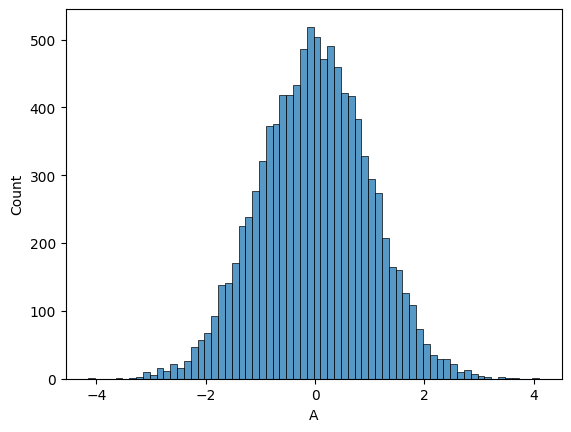

In [89]:
sns.histplot(data=df, x='A')

In [90]:
df.std()# std()函数用于计算每一列的标准差，返回一个包含每一列标准差的Series对象。

A    0.996940
B    0.993181
C    0.996544
D    1.008781
dtype: float64

In [91]:
df

,A,B,C,D
0,0.856142,-1.618230,1.068926,-0.618905
1,1.683051,0.548018,-0.666962,-2.339710
2,-1.374651,0.517803,-0.317258,2.061877
3,0.173643,0.582989,-0.343016,-0.346757
4,0.483510,1.976906,-0.221034,0.388419
...,...,...,...,...
9995,0.387475,0.143980,1.560482,1.089766
9996,-0.382579,0.464981,0.467115,1.133020
9997,-0.256996,-1.611154,-0.204144,-0.829081
9998,-0.263203,0.404598,-0.044442,-1.255581


In [92]:
np.abs(df)# abs()函数用于计算每个元素的绝对值，返回一个新的DataFrame对象。

,A,B,C,D
0,0.856142,1.618230,1.068926,0.618905
1,1.683051,0.548018,0.666962,2.339710
2,1.374651,0.517803,0.317258,2.061877
3,0.173643,0.582989,0.343016,0.346757
4,0.483510,1.976906,0.221034,0.388419
...,...,...,...,...
9995,0.387475,0.143980,1.560482,1.089766
9996,0.382579,0.464981,0.467115,1.133020
9997,0.256996,1.611154,0.204144,0.829081
9998,0.263203,0.404598,0.044442,1.255581


In [93]:
np.abs(df) > 3 * df.std()# abs()函数用于计算每个元素的绝对值，返回一个新的DataFrame对象。df.std()计算每一列的标准差，返回一个包含每一列标准差的Series对象。然后将每个元素的绝对值与对应列的标准差乘以3进行比较，返回一个布尔型的DataFrame对象，表示每个元素是否大于3倍标准差。

,A,B,C,D
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
9995,False,False,False,False
9996,False,False,False,False
9997,False,False,False,False
9998,False,False,False,False


In [94]:
exp_condition = (np.abs(df) > 3 * df.std()).any(axis=1)# any()函数用于检查DataFrame或Series中是否存在任何True值。如果存在至少一个True值，返回True；否则返回False。默认情况下，any()函数沿着列方向（axis=0）进行操作，即检查每一列是否存在True值。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

In [95]:
exp_condition

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [96]:
df.loc[exp_condition]

,A,B,C,D
148,-1.280678,-0.556227,-0.355135,3.159746
159,-3.006623,0.183117,0.148817,0.240754
240,1.202256,1.887520,1.035192,-3.156653
377,-0.427592,1.039523,0.039015,-3.337592
405,3.024358,1.479599,0.042756,0.601410
...,...,...,...,...
9358,-3.038147,-0.235212,-0.105546,0.238216
9463,0.009641,0.387483,3.683597,-0.568689
9801,1.694642,0.565460,3.203613,-0.874613
9899,2.210348,-1.297317,-3.308391,1.097410


In [97]:
normal_condition = ~exp_condition# ~运算符用于对布尔型的Series对象进行取反操作，即将True变为False，False变为True。
normal_condition

0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Length: 10000, dtype: bool

In [98]:
df.loc[normal_condition] # 过滤掉异常值

,A,B,C,D
0,0.856142,-1.618230,1.068926,-0.618905
1,1.683051,0.548018,-0.666962,-2.339710
2,-1.374651,0.517803,-0.317258,2.061877
3,0.173643,0.582989,-0.343016,-0.346757
4,0.483510,1.976906,-0.221034,0.388419
...,...,...,...,...
9995,0.387475,0.143980,1.560482,1.089766
9996,-0.382579,0.464981,0.467115,1.133020
9997,-0.256996,-1.611154,-0.204144,-0.829081
9998,-0.263203,0.404598,-0.044442,-1.255581


#### df.dropna()函数：删除所有包含缺失值的行，返回一个新的DataFrame对象。

In [99]:
df.loc[exp_condition].index

Index([ 148,  159,  240,  377,  405,  646,  663,  682,  734,  744,
       ...
       9026, 9035, 9061, 9229, 9270, 9358, 9463, 9801, 9899, 9919],
      dtype='int64', length=104)

In [100]:
df.drop(labels=df.loc[exp_condition].index, axis=0)# drop()函数用于删除指定的行或列，labels参数指定要删除的行或列的标签，axis=0表示删除行，inplace=True表示在原DataFrame上进行修改。

,A,B,C,D
0,0.856142,-1.618230,1.068926,-0.618905
1,1.683051,0.548018,-0.666962,-2.339710
2,-1.374651,0.517803,-0.317258,2.061877
3,0.173643,0.582989,-0.343016,-0.346757
4,0.483510,1.976906,-0.221034,0.388419
...,...,...,...,...
9995,0.387475,0.143980,1.560482,1.089766
9996,-0.382579,0.464981,0.467115,1.133020
9997,-0.256996,-1.611154,-0.204144,-0.829081
9998,-0.263203,0.404598,-0.044442,-1.255581


#### 使用上四分位数和下四分位数识别异常值

In [101]:
order = pd.read_excel('电商用户数据.xlsx')# 读取 Excel 文件,默认读取第一个工作表。

In [102]:
order

,买家昵称,付款日期,订单状态,实付金额,邮费,省份,城市,购买数量
0,山月同学0001,2025-04-20 16:40:39.796,交易成功,859.25,0,江苏,南通,5
1,南瓜同学0002,2025-12-19 01:09:57.045,交易成功,1683.73,0,安徽,合肥,5
2,青柚买手0003,2025-03-13 05:21:31.262,待发货,1646.42,0,浙江,嘉兴,5
3,山月生活家0004,2025-10-31 22:10:53.222,交易成功,387.61,0,湖南,长沙,5
4,海风优选0005,2025-07-21 02:12:22.722,交易成功,523.95,0,重庆,重庆,5
...,...,...,...,...,...,...,...,...
995,柠檬生活家0996,2026-02-23 21:07:49.775,交易成功,164.59,0,江苏,常州,1
996,山月会员0997,2026-03-11 07:31:03.859,交易关闭,114.29,0,陕西,渭南,1
997,松果生活家0998,2025-09-01 22:27:36.453,交易成功,375.58,0,湖南,岳阳,4
998,星河掌柜0999,2025-06-03 02:54:00.463,交易成功,394.92,0,福建,莆田,4


In [103]:
order.info()# info()函数用于查看DataFrame的基本信息，包括数据类型、非空值数量、内存占用等。

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   买家昵称    1000 non-null   str           
 1   付款日期    1000 non-null   datetime64[us]
 2   订单状态    1000 non-null   str           
 3   实付金额    1000 non-null   float64       
 4   邮费      1000 non-null   int64         
 5   省份      1000 non-null   str           
 6   城市      1000 non-null   str           
 7   购买数量    1000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 62.6 KB


In [104]:
order.describe(percentiles=[0.25, 0.5, 0.75, 0.99])# describe()函数用于快速查看数据的统计信息，包括计数、均值、标准差、最小值、最大值等。

,付款日期,实付金额,邮费,购买数量
count,1000,1000.000000,1000.000000,1000.000000
mean,2025-10-13 09:13:17.003573,567.940150,0.504000,3.009000
min,2024-12-31 17:48:41.019000,20.620000,0.000000,1.000000
25%,2025-05-29 00:49:57.618250,237.607500,0.000000,2.000000
50%,2025-10-11 16:00:28.524000,449.355000,0.000000,3.000000
75%,2026-02-26 15:49:10.699500,832.845000,0.000000,4.000000
99%,2026-07-04 05:16:05.670370,1683.800500,12.000000,5.000000
max,2026-07-09 00:13:15.288000,1856.050000,12.000000,5.000000
std,NaN,421.772901,2.083825,1.412414


<Axes: ylabel='实付金额'>

/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20184 (\N{CJK UNIFIED IDEOGRAPH-4ED8}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:17

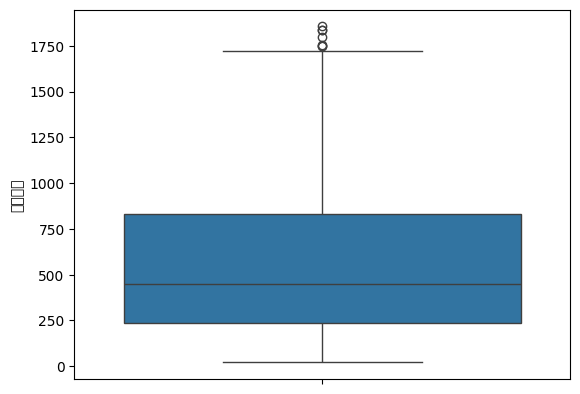

In [105]:
sns.boxplot(y= order['实付金额'])# boxplot()函数用于绘制箱线图，显示数据的分布情况，包括中位数、四分位数、异常值等。

- BOTTOM = Q1 - 1.5 * IQR
- UPPER = Q3 + 1.5 * IQR

In [106]:
Q1, Q3 = np.quantile(order['实付金额'], q=[0.25, 0.75])# quantile()函数用于计算指定分位数的值，q参数指定要计算的分位数。
IQR = Q3 - Q1
BOTTOM = Q1 - 1.5 * IQR
UPPER = Q3 + 1.5 * IQR

In [107]:
order['实付金额']> UPPER

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: 实付金额, Length: 1000, dtype: bool

In [108]:
order['实付金额']< BOTTOM

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: 实付金额, Length: 1000, dtype: bool

In [109]:
exp_condition = (order['实付金额']>UPPER)| (order['实付金额']<BOTTOM)
exp_condition

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: 实付金额, Length: 1000, dtype: bool

In [110]:
order.loc[exp_condition]

,买家昵称,付款日期,订单状态,实付金额,邮费,省份,城市,购买数量
97,南瓜优选0098,2026-03-27 12:39:04.560,交易成功,1747.34,0,北京,北京,5
429,海风买手0430,2025-10-08 22:03:06.788,已付款,1856.05,0,河北,保定,5
430,白茶优选0431,2025-06-22 14:44:01.148,退款成功,1835.17,0,广东,佛山,5
649,青柚用户0650,2025-04-28 07:43:51.329,退款成功,1837.28,0,湖北,襄阳,5
668,柠檬会员0669,2025-03-03 21:36:19.109,交易成功,1755.85,0,广东,珠海,5
689,南瓜达人0690,2025-04-27 09:06:08.848,已付款,1749.36,0,四川,德阳,5
707,白茶用户0708,2025-09-26 00:53:39.830,已发货,1799.64,0,安徽,安庆,5


In [111]:
order.loc[exp_condition].index

Index([97, 429, 430, 649, 668, 689, 707], dtype='int64')

In [112]:
order.drop(labels=order.loc[exp_condition].index, axis=0)

,买家昵称,付款日期,订单状态,实付金额,邮费,省份,城市,购买数量
0,山月同学0001,2025-04-20 16:40:39.796,交易成功,859.25,0,江苏,南通,5
1,南瓜同学0002,2025-12-19 01:09:57.045,交易成功,1683.73,0,安徽,合肥,5
2,青柚买手0003,2025-03-13 05:21:31.262,待发货,1646.42,0,浙江,嘉兴,5
3,山月生活家0004,2025-10-31 22:10:53.222,交易成功,387.61,0,湖南,长沙,5
4,海风优选0005,2025-07-21 02:12:22.722,交易成功,523.95,0,重庆,重庆,5
...,...,...,...,...,...,...,...,...
995,柠檬生活家0996,2026-02-23 21:07:49.775,交易成功,164.59,0,江苏,常州,1
996,山月会员0997,2026-03-11 07:31:03.859,交易关闭,114.29,0,陕西,渭南,1
997,松果生活家0998,2025-09-01 22:27:36.453,交易成功,375.58,0,湖南,岳阳,4
998,星河掌柜0999,2025-06-03 02:54:00.463,交易成功,394.92,0,福建,莆田,4


### 处理异常值

两个方法：过滤和删除

## 重复值处理

In [113]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。

In [114]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,9,96,7
3,86,24,20
4,7,72,84
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


In [115]:
df.loc[2] = df.loc[6]
df.loc[3] = df.loc[7]
df.loc[4] = df.loc[8]

In [116]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,78,52,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


In [117]:
df.loc[2, 'B'] = 100

In [118]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


### 检查

df.duplicated()函数：用于检查DataFrame或Series中是否存在重复值，返回一个布尔型的Series对象，重复值为True，非重复值为False。

In [119]:
df.duplicated()
# keep='first'表示保留第一次出现的重复值，其他重复值标记为True。
# subset=['A', 'B']表示只考虑'A'和'B'列，其他列的值不影响重复值的判断。

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8     True
9    False
dtype: bool

### 过滤

In [120]:
condition = df.duplicated(keep='first', subset=['A', 'C'])
condition

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7     True
8     True
9    False
dtype: bool

In [121]:
df.loc[~condition]

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
9,53,31,35


### 删除

In [122]:
df.drop(labels=df.loc[condition].index, axis=0)# drop()函数用于删除指定的行或列，labels参数指定要删除的行或列的标签，axis=0表示删除行，inplace=True表示在原DataFrame上进行修改。

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
9,53,31,35


In [123]:
df.drop_duplicates(subset=['A', 'C'])# drop_duplicates()函数用于删除重复的行，subset参数指定要考虑的列，inplace=True表示在原DataFrame上进行修改。

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
9,53,31,35


## Pandas排序与随机抽样

In [124]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


In [125]:
df.sort_values(by='A')# sort_values()函数用于对DataFrame进行排序，by参数指定要排序的列名，默认升序排列。

,A,B,C
4,10,49,46
8,10,49,46
3,30,37,29
7,30,37,29
5,44,28,7
9,53,31,35
1,71,47,68
2,78,100,89
6,78,52,89
0,97,17,95


In [126]:
# 指定多列排序
df.sort_values(by=['A', 'B'], ascending=False)# sort_values()函数用于对DataFrame进行排序，by参数指定要排序的列名，ascending参数指定每一列的排序顺序，False表示降序排列。

,A,B,C
0,97,17,95
2,78,100,89
6,78,52,89
1,71,47,68
9,53,31,35
5,44,28,7
3,30,37,29
7,30,37,29
4,10,49,46
8,10,49,46


In [127]:
# 根据索引排序
df.sort_index(ascending=False)# sort_index()函数用于根据索引对DataFrame进行排序，默认升序排列。

,A,B,C
9,53,31,35
8,10,49,46
7,30,37,29
6,78,52,89
5,44,28,7
4,10,49,46
3,30,37,29
2,78,100,89
1,71,47,68
0,97,17,95


#### 随机抽样
- sample()函数：用于从DataFrame或Series中随机抽样数据，可以指定抽样的数量或比例。
- take()函数：用于根据指定的索引位置从DataFrame或Series中获取数据。

In [128]:
df.sample(n=2)# sample()函数用于从DataFrame或Series中随机抽样数据，可以指定抽样的数量或比例。    

,A,B,C
8,10,49,46
6,78,52,89


In [129]:
index = np.random.randint(0, 10, size=3)
index

array([0, 7, 2])

In [130]:
df.take(index)# take()函数用于根据指定的索引位置从DataFrame或Series中获取数据。

,A,B,C
0,97,17,95
7,30,37,29
2,78,100,89


## 索引设置

In [131]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


- set_index('A')# set_index()函数用于将指定的列设置为索引列，inplace=True表示在原DataFrame上进行修改。

In [132]:
df.set_index('A')

,B,C
A,,
97,17,95
71,47,68
78,100,89
30,37,29
10,49,46
44,28,7
78,52,89
30,37,29
10,49,46


In [133]:
df1 = df.set_index('A')# set_index()函数用于将指定的列设置为索引列，inplace=True表示在原DataFrame上进行修改。
df1

,B,C
A,,
97,17,95
71,47,68
78,100,89
30,37,29
10,49,46
44,28,7
78,52,89
30,37,29
10,49,46


- reset_index()# reset_index()函数用于将索引列重置为默认的整数索引，inplace=True表示在原DataFrame上进行修改。

In [134]:
df1.reset_index()

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


### reindex()# reindex()函数用于根据指定的索引重新排列DataFrame或Series的数据，可以添加新的索引或删除现有的索引。

In [135]:
df2 = df.reset_index(level=-1)

In [136]:
df2

,index,A,B,C
0,0,97,17,95
1,1,71,47,68
2,2,78,100,89
3,3,30,37,29
4,4,10,49,46
5,5,44,28,7
6,6,78,52,89
7,7,30,37,29
8,8,10,49,46
9,9,53,31,35


In [137]:
df2.reindex(labels = ['A', 'B', 'D', 'E'],axis=1)# reindex()函数用于根据指定的索引重新排列DataFrame或Series的数据，可以添加新的索引或删除现有的索引。labels参数指定新的索引标签，axis=1表示沿着列方向进行重新排列。

,A,B,D,E
0,97,17,NaN,NaN
1,71,47,NaN,NaN
2,78,100,NaN,NaN
3,30,37,NaN,NaN
4,10,49,NaN,NaN
5,44,28,NaN,NaN
6,78,52,NaN,NaN
7,30,37,NaN,NaN
8,10,49,NaN,NaN
9,53,31,NaN,NaN


### droplevel()# droplevel()函数用于删除多级索引中的指定级别，返回一个新的DataFrame或Series对象。

In [138]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


In [139]:
df3 = df.set_index(['A', 'B'])# set_index()函数用于将指定的列设置为索引列，inplace=True表示在原DataFrame上进行修改。

In [140]:
df3

,,C
A,B,
97,17,95
71,47,68
78,100,89
30,37,29
10,49,46
44,28,7
78,52,89
30,37,29
10,49,46


In [141]:
df3.droplevel(level=-1)# droplevel()函数用于删除多级索引中的指定级别，返回一个新的DataFrame或Series对象。

,C
A,
97,95
71,68
78,89
30,29
10,46
44,7
78,89
30,29
10,46


## 映射处理

#### rename()函数：用于重命名DataFrame或Series的索引或列标签，可以通过传入字典来指定新的标签名称。

In [142]:
df

,A,B,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


In [143]:
df.rename(mapper=lambda x: str(x)+'产品',axis=1)# rename()函数用于重命名DataFrame或Series的索引或列标签，可以通过传入字典来指定新的标签名称。columns参数指定要重命名的列，index参数指定要重命名的索引。

,A产品,B产品,C产品
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


In [144]:
df.rename(columns={'A': 'a', 'B': 'b'})# rename()函数用于重命名DataFrame或Series的索引或列标签，可以通过传入字典来指定新的标签名称。columns参数指定要重命名的列，index参数指定要重命名的索引。

,a,b,C
0,97,17,95
1,71,47,68
2,78,100,89
3,30,37,29
4,10,49,46
5,44,28,7
6,78,52,89
7,30,37,29
8,10,49,46
9,53,31,35


#### replace()函数：用于替换DataFrame或Series中的指定值，可以通过传入字典来指定要替换的值和新的值。

In [145]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。

In [146]:
df

,A,B,C
0,23,66,86
1,44,48,76
2,73,99,11
3,43,68,32
4,50,55,4
5,87,28,94
6,95,69,39
7,14,26,6
8,60,72,57
9,54,40,84


In [160]:
df.replace(to_replace=[23, 28], value='hi')# replace()函数用于替换DataFrame或Series中的指定值，可以通过传入字典来指定要替换的值和新的值。to_replace参数指定要替换的值，value参数指定新的值，inplace参数指定是否在原DataFrame上进行修改。

IndexError: pop index out of range

#### map()函数：用于将一个函数应用于DataFrame或Series的每个元素，返回一个新的对象。

In [148]:
df

,A,B,C
0,23,66,86
1,44,48,76
2,73,99,11
3,43,68,32
4,50,55,4
5,87,28,94
6,95,69,39
7,14,26,6
8,60,72,57
9,54,40,84


In [149]:
def score_map(x):
    if x >= 90:
        return '优秀'
    elif x >= 80:
        return '良好'
    elif x >= 70:
        return '中等'
    elif x >= 60:
        return '及格'
    else:
        return '不及格'

In [150]:
df.loc[:, 'A'].map(score_map)

0    不及格
1    不及格
2     中等
3    不及格
4    不及格
5     良好
6     优秀
7    不及格
8     及格
9    不及格
Name: A, dtype: str

In [151]:
df.map(score_map)

,A,B,C
0,不及格,及格,良好
1,不及格,不及格,中等
2,中等,优秀,不及格
3,不及格,及格,不及格
4,不及格,不及格,不及格
5,良好,不及格,优秀
6,优秀,及格,不及格
7,不及格,不及格,不及格
8,及格,中等,不及格
9,不及格,不及格,良好


In [152]:
df

,A,B,C
0,23,66,86
1,44,48,76
2,73,99,11
3,43,68,32
4,50,55,4
5,87,28,94
6,95,69,39
7,14,26,6
8,60,72,57
9,54,40,84


In [153]:
def map_func(x):
    if x >= 90:
        return '优秀'
    elif x >= 80:
        return '良好'
    elif x >= 70:
        return '中等'
    elif x >= 60:
        return '及格'

In [154]:
# 使用map()函数对DataFrame进行映射,如果map_func()函数返回None，则表示该元素不满足任何条件，可以根据需要进行处理，例如返回一个默认值或抛出异常。
df.map(map_func)

,A,B,C
0,NaN,及格,良好
1,NaN,NaN,中等
2,中等,优秀,NaN
3,NaN,及格,NaN
4,NaN,NaN,NaN
5,良好,NaN,优秀
6,优秀,及格,NaN
7,NaN,NaN,NaN
8,及格,中等,NaN
9,NaN,NaN,良好


In [155]:
df.map(lambda x: len(str(x)))

,A,B,C
0,2,2,2
1,2,2,2
2,2,2,2
3,2,2,2
4,2,2,1
5,2,2,2
6,2,2,2
7,2,2,1
8,2,2,2
9,2,2,2


In [156]:
df_copy = df.copy()

In [157]:
df_copy.iloc[0, 0] = pd.NA

In [158]:
df_copy

,A,B,C
0,NaN,66,86
1,44.0,48,76
2,73.0,99,11
3,43.0,68,32
4,50.0,55,4
5,87.0,28,94
6,95.0,69,39
7,14.0,26,6
8,60.0,72,57
9,54.0,40,84


In [159]:
df_copy.map(lambda x: len(str(x)), na_action="ignore")

,A,B,C
0,NaN,2,2
1,4.0,2,2
2,4.0,2,2
3,4.0,2,2
4,4.0,2,1
5,4.0,2,2
6,4.0,2,2
7,4.0,2,1
8,4.0,2,2
9,4.0,2,2
